# Dark-matter quantum-sensor response analysis

Forward + inverse analysis on the Mathematica response matrices
(`../Mathematica/output/TES/response_matrix/`).

`observed = exposure · M @ η` → recover a monotone, non-negative flux that
reproduces the energy-bin counts. No tuned constants: grids come from the
matrix files, the exposure from `constants`, the conditioning from the data.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from quantum_sensor import DarkMatterQuantumAnalysis, RunConfig

## TES (Al), heavy mediator (q0), 5 energy bins, Halo halo, signal only

M1: 5 E-bins x 948 v_min bins, peak flux 4.53e-26
M2: 5 E-bins x 985 v_min bins, peak flux 4.18e-27
M3: 5 E-bins x 996 v_min bins, peak flux 4.20e-28


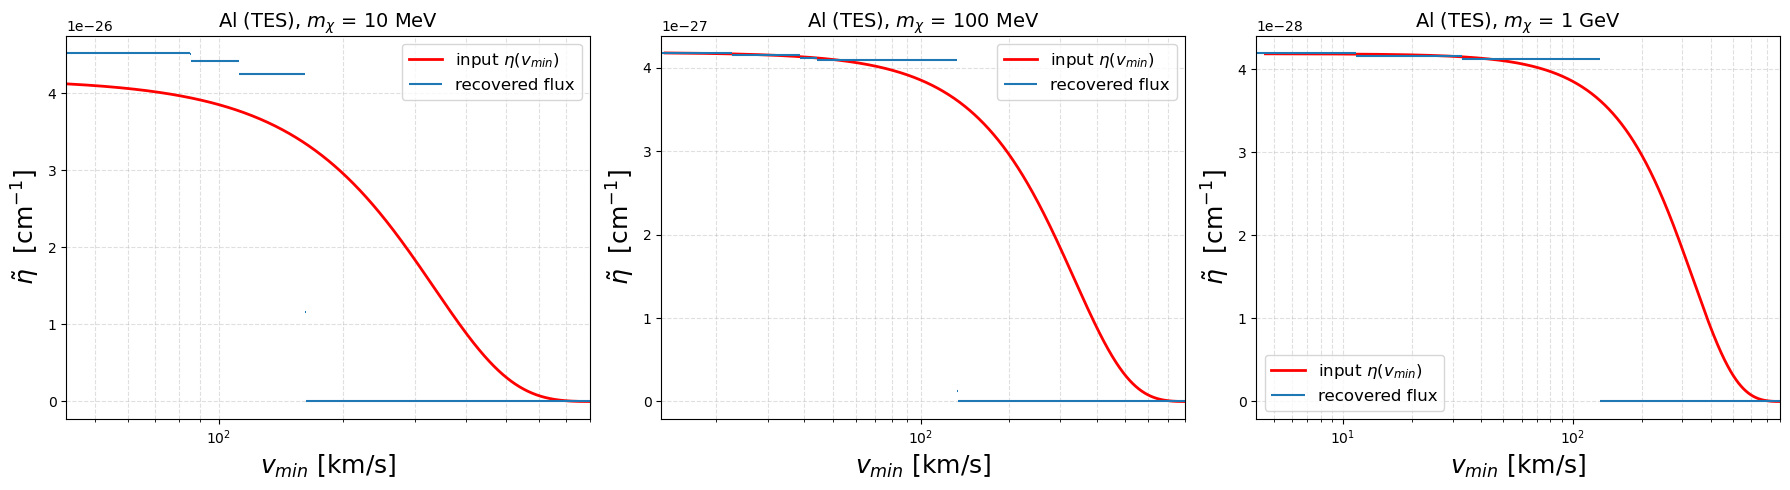

In [2]:
masses = {'1': '10 MeV', '2': '100 MeV', '3': '1 GeV'}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (mass, label) in zip(axes, masses.items()):
    a = DarkMatterQuantumAnalysis(
        RunConfig(material='Al', q='0', mass=mass, nbins=5, eta='Halo', background='none'))
    flux = a.optimize(solver='osqp')
    a.plot(save=False, ax=ax)
    ax.set_title(f'Al (TES), $m_\\chi$ = {label}', fontsize=14)
    print(f'M{mass}: {a.n_ebins} E-bins x {a.n_vmin} v_min bins, peak flux {flux.max():.2e}')
plt.tight_layout(); plt.show()

## Light mediator (q2)

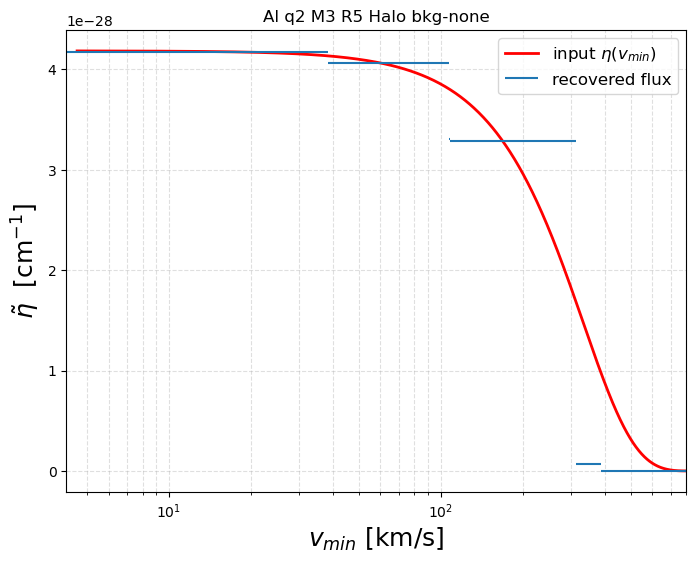

In [3]:
a = DarkMatterQuantumAnalysis(
    RunConfig(material='Al', q='2', mass='3', nbins=5, eta='Halo', background='none'))
a.optimize(solver='osqp')
a.plot(save=False); plt.show()

## Finer energy binning (R10)

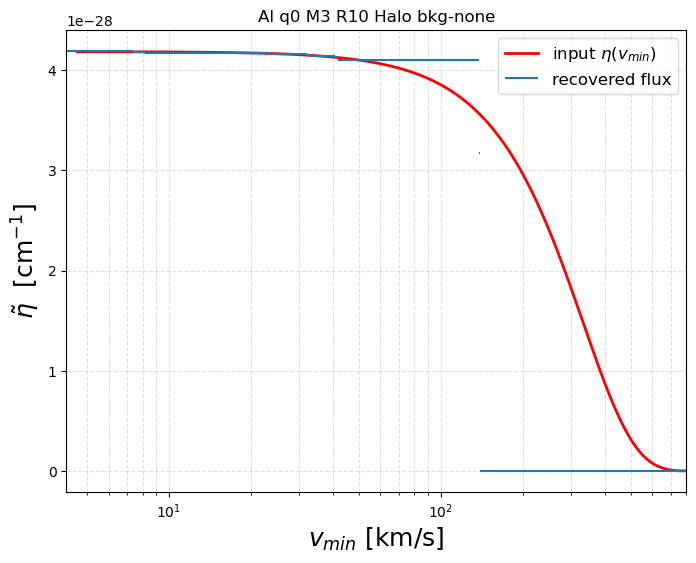

In [4]:
a = DarkMatterQuantumAnalysis(
    RunConfig(material='Al', q='0', mass='3', nbins=10, eta='Halo', background='none'))
a.optimize(solver='osqp')
a.plot(save=False); plt.show()

## With a background scenario

`background='c'` adds the medium background spectrum to the observed counts.

signal     : [11802.80244558 22938.75961884 34145.51677659 45102.40330222
 55790.66809748]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]


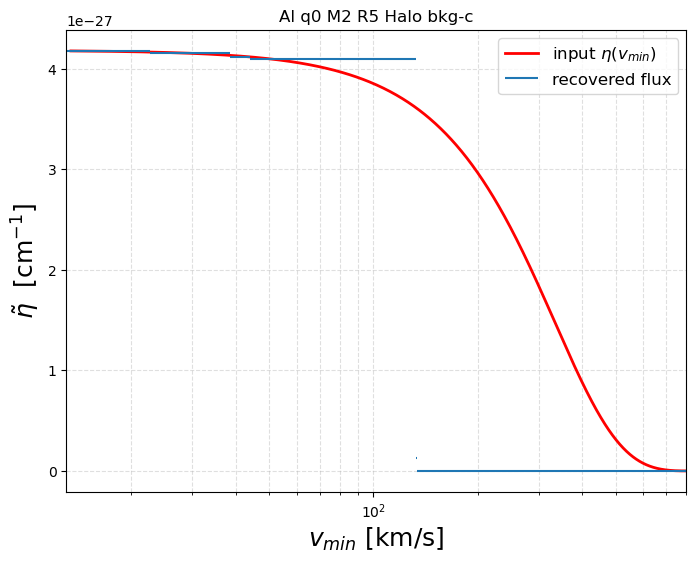

In [5]:
a = DarkMatterQuantumAnalysis(
    RunConfig(material='Al', q='0', mass='2', nbins=5, eta='Halo', background='c'))
a.optimize(solver='osqp')
print('signal     :', a.signal)
print('background :', a.background)
a.plot(save=False); plt.show()